In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Vertical Multipath Effect at Different Mounting Heights

Radar signals reflecting off the ground create **vertical multipath**: direct + reflected paths interfere, producing amplitude lobing (constructive/destructive interference) that varies with range and mounting height.

### This Example

- **Radar**: 76.5 GHz FMCW, 160 MHz BW, monostatic
- **Target**: Corner reflector swept from 300 m → 10 m (−1 m/s)
- **Heights tested**: 0.2 m, 0.6 m, 1.0 m above ground
- **Comparison**: Amplitude with ground vs. free-space reference → normalized RCS shows multipath-induced lobing
- **Expected**: Oscillating pattern superimposed on 1/R⁴ decay; lobing period and null positions shift with height

## Create Radar Model

### Import Required Modules

In [2]:
import numpy as np
import plotly.graph_objs as go
from IPython.display import Image, display
from radarsimpy import Radar, Transmitter, Receiver

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

### Transmitter

76.5 GHz FMCW with 160 MHz bandwidth → ΔR ≈ 0.94 m. Single chirp per frame; 290 frames at 1 s intervals capture the target as it moves from 300 m → 10 m.

In [3]:
tx_channel = dict(
    location=(0, 0, 0),
)

tx = Transmitter(
    f=[76.5e9 - 80e6, 76.5e9 + 80e6],
    t=20e-6,
    tx_power=15,
    prp=100e-6,
    pulses=1,
    channels=[tx_channel],
)

### Receiver

| Parameter | Value | Notes |
|-----------|-------|-------|
| Sampling rate | 20 MHz | R_max ≈ 300 m |
| Noise figure | 8 dB | |
| RF gain | 20 dB | |
| BB gain | 80 dB | High sensitivity |
| Load resistor | 1000 Ω | |

In [4]:
rx_channel = dict(
    location=(0, 0, 0),
)

rx = Receiver(
    fs=20e6,
    noise_figure=8,
    rf_gain=20,
    load_resistor=1000,
    baseband_gain=80,
    channels=[rx_channel],
)

### Radar System

First simulate the free-space case (no ground) to establish a reference. Then simulate three mounting heights with ground plane to observe multipath effects.

In [5]:
from radarsimpy.simulator import sim_radar
from scipy import signal
import radarsimpy.processing as proc
import time

radar = Radar(
    transmitter=tx, receiver=rx, location=(0, 0, 0), frame_time=np.arange(0, 290, 1)
)

target_1 = {"model": "../models/cr.stl", "location": (300, 0, 0), "speed": (-1, 0, 0)}

targets = [target_1]

data = sim_radar(radar, targets, density=0.5)
baseband = data["baseband"]

range_window = signal.windows.chebwin(radar.sample_prop["samples_per_pulse"], at=60)
range_profile = proc.range_fft(baseband, range_window)

amp_single = np.max(20 * np.log10(np.abs(range_profile)), axis=2)

In [6]:
mount_height = [0.2, 0.6, 1.0]

amp_multi = np.zeros((len(mount_height), 290), dtype=np.float64)

for idx, height in enumerate(mount_height):
    radar = Radar(
        transmitter=tx, receiver=rx, location=(0, 0, height), frame_time=np.arange(0, 290, 1)
    )

    target_1 = {
        "model": "../models/cr.stl",
        "location": (300, 0, height),
        "speed": (-1, 0, 0),
        "rotation": (0, 0, 0),
    }

    target_2 = {
        "model": "../models/surface_400x400.stl",
        "location": (0, 0, 0),
        "speed": (0, 0, 0),
        "permittivity": 3.2 + 0.1j,
        "skip_diffusion": True,
    }
    targets = [target_1, target_2]

    data = sim_radar(radar, targets, density=0.5)
    baseband = data["baseband"]

    range_window = signal.windows.chebwin(radar.sample_prop["samples_per_pulse"], at=60)
    range_profile = proc.range_fft(baseband, range_window)

    amp_multi[idx, :] = np.max(20 * np.log10(np.abs(range_profile)), axis=2).flatten()

## Results

Four multipath propagation paths interfere:

| Path | Route | Notes |
|------|-------|-------|
| Direct | TX → Target → RX | Shortest |
| TX reflection | TX → Ground → Target → RX | One bounce |
| RX reflection | TX → Target → Ground → RX | One bounce |
| Two-bounce | TX → Ground → Target → Ground → RX | Longest, most attenuated |

Phase differences between paths create the lobing pattern. Mounting height controls the null positions and lobing period: higher antennas → more closely spaced nulls.

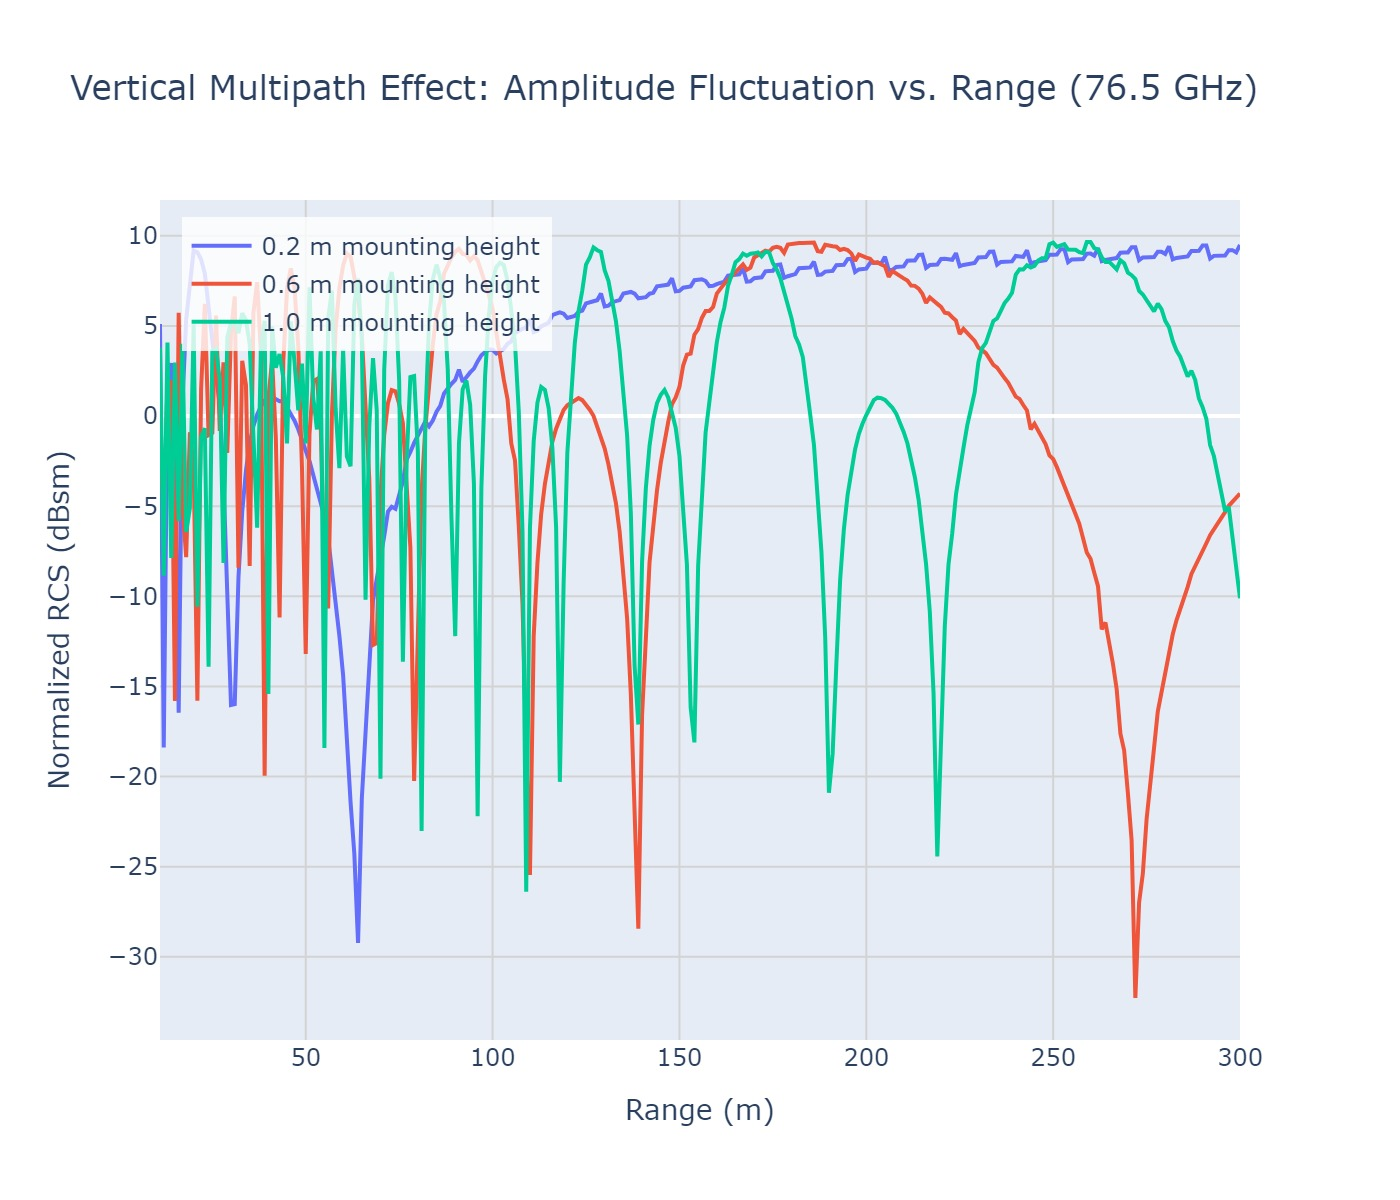

In [7]:
# Range axis: target sweeps 300 m → 10 m over 290 frames
t_range = 10 + np.arange(290, 0, -1) * 1  # [300, 299, ..., 11] meters

fig = go.Figure()

for idx, height in enumerate(mount_height):
    fig.add_trace(
        go.Scatter(
            x=t_range,
            y=amp_multi[idx, :] - amp_single.flatten(),
            name=str(np.round(height, 1)) + " m mounting height",
            mode="lines",
            line=dict(width=2),
        )
    )

fig.update_layout(
    title="Vertical Multipath Effect: Amplitude Fluctuation vs. Range (76.5 GHz)",
    yaxis=dict(title="Normalized RCS (dBsm)", gridcolor="lightgray"),
    xaxis=dict(title="Range (m)", gridcolor="lightgray"),
    height=600,
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(255,255,255,0.8)"),
    hovermode="x unified",
)

show(fig)

## Summary

- Vertical multipath from ground reflections creates amplitude lobing — oscillating constructive/destructive interference superimposed on the 1/R⁴ free-space decay
- Four paths interfere: direct, TX-side reflection, RX-side reflection, and two-bounce
- Mounting height dramatically affects the lobing pattern: 0.2 m produces slower oscillations (fewer nulls); 1.0 m produces faster oscillations (more nulls over the same range)
- Normalized RCS (with ground minus free-space) reveals the pure multipath contribution, removing the range-dependent attenuation
- Ground permittivity (ε_r = 3.2 + 0.1j for asphalt/concrete) controls reflection strength via the Fresnel coefficient

### Things to Try

| Experiment | How |
|------------|-----|
| Change mounting height | Test 0.1 m, 0.4 m, 1.5 m, 2.0 m; observe null spacing vs. height |
| Vary frequency | Use 24 GHz or 94 GHz; lobing period scales with λ |
| Different ground materials | Change `permittivity` (dry soil: 3+0.05j, wet soil: 20+2j); observe null depth |
| Adjust target height | Match radar height or vary independently; affects null positions |
| Extend range sweep | Start from 500 m; observe more lobing cycles |
| Diffuse scattering | Set `skip_diffusion=False` on ground; softer nulls from rough surfaces |

### Resources

- [RadarSimPy Documentation](https://radarsimx.com/radarsimpy/)
- [Multipath Propagation](https://ieeexplore.ieee.org/document/564289) — IEEE Trans. AP, 1996
- [Two-Ray Ground Reflection Model](https://en.wikipedia.org/wiki/Two-ray_ground-reflection_model)